# News Article Classification (Fake/Real)

## Internship Project

### Name: Chandrashekharayya Hosmath
### Domain: Artificial Intelligence & Machine Learning

### Objective
The objective of this project is to classify news articles as Fake or Real using Machine Learning and Natural Language Processing (NLP) techniques.

# Import Required Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK Stopwords

In [8]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Chandru\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

# Load Dataset

In [13]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")
print("Fake News Shape:", fake.shape)
print("Real News Shape:", real.shape)

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


# Assign Labels

In [15]:
fake["label"] = 0
real["label"] = 1

# Merge Dataset

In [16]:
df = pd.concat([fake, real])
df = df.sample(frac=1, random_state=42)
df.head()

,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
4436,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
1526,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
8995,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


# Dataset Information

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 22216 to 15795
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [19]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [20]:
df.shape

(44898, 5)

# Data Cleaning

In [21]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [22]:
df["text"] = df["text"].apply(clean_text)
df["text"].head()

22216    st century wire says ben stein reputable profe...
4436     washington reuters u president donald trump re...
1526     reuters puerto rico governor ricardo rossello ...
1377     monday donald trump embarrassed country accide...
8995     glasgow scotland reuters u presidential candid...
Name: text, dtype: object

# Feature Selection

In [24]:
X = df["text"]
y = df["label"]

# Convert Text into Numerical Features using TF-IDF

In [25]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

# Split Dataset into Training and Testing Data

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (35918, 5000)
Testing Data: (8980, 5000)


# Train Logistic Regression Model

In [27]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Make Predictions

In [28]:
y_pred = model.predict(X_test)

# Evaluate Model Performance

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.984966592427617


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.99      0.98      8980
weighted avg       0.98      0.98      0.98      8980



# Confusion Matrix

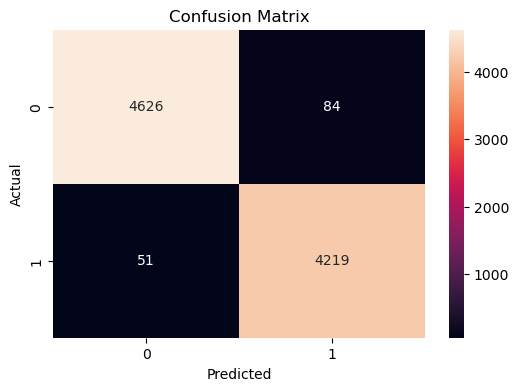

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Save Model

In [32]:
import pickle
pickle.dump(model,
            open("model.pkl","wb"))
pickle.dump(vectorizer,
            open("vectorizer.pkl","wb"))
print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

In this project, I built a Fake News Detection model using Machine Learning. The news articles were converted into numerical features using TF-IDF and classified using Logistic Regression. The model achieved good accuracy in identifying fake and real news.